Taller final mecánica de sólidos

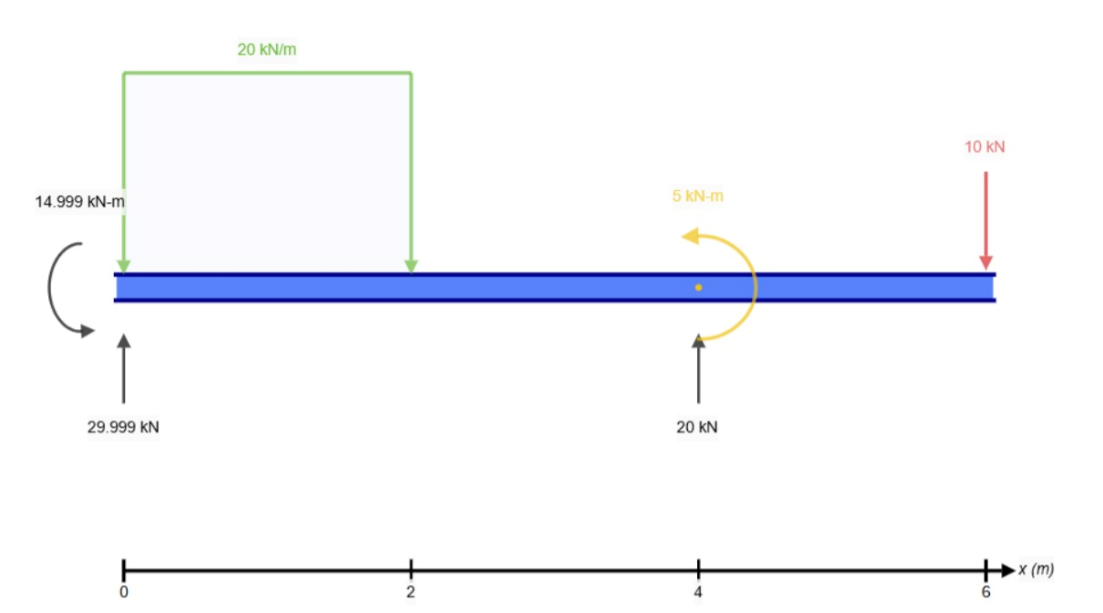

importo librerias

In [1]:
from sympy import lambdify, Piecewise, integrate, symbols, Eq, solve
from sympy.abc import x
from numpy import sum, array, linspace, meshgrid, argmin, argmax, percentile, pi, sqrt, arctan2, unravel_index, maximum, cos, sin, ndarray
import matplotlib.pyplot as plt

# Datos de entrada

Sección transversal:

In [2]:
bx  = 0.30            # [m]
hy  = 0.40            # [m]
I = (bx*hy**3)/12     # [m^4] Cálculo de la inercia.

$f'c=21MPa$ (resistencia a compresión del concreto)

$E = 4700 \sqrt{f'c}$ en MPa según la sección C.8.5 de la NSR-10

In [3]:
fpc = 21              # [MPa]
Ei = 4700*(fpc)**0.5  # [MPa]
E = Ei*1000           # [kPa]
nu = 0.23            # Coeficiente de Poisson.
G = E/(2*(1 + nu))   # [kN/m2] Módulo de cortante.

In [4]:
x, y       = symbols("x, y")           # Variables de posición.
C3, C4     = symbols("C3, C4")         # Constantes de integración.
RA, RB, MA = symbols("R_A, R_B, M_A")  # Reacciones.

In [5]:
# Función con la condición de Macaulay, a: punto de discontinuidad, n:grado
macaulay = lambda a, n : Piecewise(((x-a)**n, (a <= x)), (0, True))

## Ecuaciones de carga, cortante y momento con un corte único

In [6]:
q = - 20*macaulay(0,0) + 20*macaulay(2,0)  # [kN/m] 
V = RA*macaulay(0, 0) -20*macaulay(0,1) +20*macaulay(2,1) +RB*macaulay(4,0)   # [kN]
M = RA*macaulay(0, 1) - MA*macaulay(0, 0) -(20/2)*macaulay(0,2) +(20/2)*macaulay(2,2) +RB*macaulay(4, 1) -5*macaulay(4, 0)   # [kN.m]

In [7]:
t = integrate(M/(E*I), x) + C3  # [RAD] Ángulo de giro.
v = integrate(t,       x) + C4  # [mm] deflexión con Euler-Bernoulli.

In [8]:
sol = solve([Eq(v.subs(x,0), 0),  # Despl vert en apoyo en x=0 es 0.
             Eq(v.subs(x,4), 0),  # Despl vert en apoyo en x=4 m es 0.
             Eq(RA - 20*2 + RB - 10 , 0),  # Sum fy=0
             Eq(MA -20*2*(1) +RB*(4) +5 -10*(6),   0),  # Sum de momentos desde A=0
             Eq(t.subs(x,0), 0),  # Ángulo de giro en x=0 es 0.
             ],
            [RA, RB, C3, C4, MA])

In [9]:
V = V.subs(sol)
M = M.subs(sol)
t = t.subs(sol)
v = v.subs(sol)

In [10]:
xi, yi = meshgrid(linspace(   0,  6, 1000),      # Dirección x.
                  linspace( -hy/2, hy/2, 1000))  # Dirección y, va de -ci hasta cs.

In [11]:
xg = xi[0]    # Extraemos la información para funciones que sólo dependen de x.
yg = yi[:,0]  # Extraemos la información para funciones que sólo dependen de y.

# Ecuaciones para hallar los esfuerzos y deformaciones 

Calculamos en la malla dada los esfuerzos $\sigma_x$ y $\tau_{xy}$ según la teoría de vigas de Euler-Bernoulli con las ecuaciones:
$$\sigma_x(x,y) = \frac{M(x)y}{I}$$
$$\tau_{xy}(x,y)=\frac{V}{2I}{(y^2-\frac{h^2}{4})}$$

Y usamos la siguiente ecuación válida para vigas con secciones simétricas respecto a $y=0$ para la carga distribuida:

$$\sigma_y(x,y)=\frac{q(x)}{2b(y)h}(2y+h)$$

De este modo, para tener en cuenta las cargas puntuales se tiene en cuenta la solución de Flamant (Seccion 6.13.3 del libro de sólidos):

$$\sigma_y^{puntual} = -\frac{2P}{\pi} \frac{y^3}{((x - x_0)^2 + y^2)^2}$$

In [12]:
sx  = -M*y/I                    # [kN/m2] Esfuerzo normal en x
txy =  V*(y**2-hy**2/4)/(2*I)  # [kN/m2] Esfuerzo cortante.

sy_dist = q*(2*y+hy)/(2*bx*hy)          # [kN/m2] Esfuerzo normal en y para cargas distribuidas.

y_flamant_mas   = (y-hy/2)              # [m] Transformación de coordenadas para Flamant.
y_flamant_menos = (y+hy/2)              # [m] Transformación de coordenadas para Flamant.
sy_point_1      = -2*(30)/pi*(y_flamant_menos**3/(((x-0)**2+y_flamant_menos**2)**2))        # [kN/m2] Esfuerzo normal en y para cargas puntuales.
sy_point_2      = -2*(20)/pi*(y_flamant_menos**3/(((x-4)**2+y_flamant_menos**2)**2))        # [kN/m2] Esfuerzo normal en y para cargas puntuales.
sy_point_3      = -2*(-10)/pi*(y_flamant_mas**3/(((x-6)**2+y_flamant_mas**2)**2))           # [kN/m2] Esfuerzo normal en y para cargas puntuales.
sy_points       = sy_point_1 + sy_point_2 + sy_point_3      # [kN/m2] Esfuerzo normal en y total.

sy = sy_dist        # [kN/m2] Esfuerzo normal en y total.

Debido a que:

$$\displaystyle \underline{\underline{\boldsymbol{\sigma}}} = \left[\begin{matrix}\sigma_{x} & \tau_{xy} & 0\\\tau_{xy} & \sigma_{y} & 0\\0 & 0 & 0\end{matrix}\right]$$

Calculamos las deformaciones con las ecuaciones de **tensión plana** para isótropos:
$$\varepsilon_x=\frac{1}{E}(\sigma_x-\nu \sigma_y)$$

$$\varepsilon_y=\frac{1}{E}(\sigma_y-\nu \sigma_x)$$

$$\varepsilon_z=-\frac{\nu}{E}(\sigma_x+\sigma_y)$$

$$\gamma_{xy}=\frac{1}{G}\tau_{xy}$$

$$\gamma_{yz}=0$$

$$\gamma_{xz}=0$$

In [13]:
ex = (1/E)*(sx - nu*sy)
ey = (1/E)*(sy - nu*sx)
ez = -(nu/E)*(sx + sy)
gxy = txy/G

## SE PASA A LA LIBRERIA NUMPY PARA OBTENER RESULTADOS

In [14]:
V  = lambdify(x, V, "numpy")
M  = lambdify(x, M, "numpy")
t  = lambdify(x, t, "numpy")
v  = lambdify(x, v, "numpy")

sx         = lambdify((x,y), sx, "numpy")
txy        = lambdify((x,y), txy, "numpy")
sy_dist    = lambdify((x,y), sy_dist, "numpy")
sy_points  = lambdify((x,y), sy_points, "numpy")
sy         = lambdify((x,y), sy, "numpy")
ex         = lambdify((x,y), ex, "numpy")
ey         = lambdify((x,y), ey, "numpy")
ez         = lambdify((x,y), ez, "numpy")
gxy        = lambdify((x,y), gxy, "numpy")

Calculamos los esfuerzos y direcciones principales a partir de las ecuaciones del capítulo 2:

$$\sigma_1=\frac{(\sigma_x+\sigma_y)}{2}+\tau_{max}$$
$$\sigma_2=\frac{(\sigma_x+\sigma_y)}{2}-\tau_{max}$$

Donde: $\tau_{máx}=R=\sqrt{\left(\frac{\sigma_x-\sigma_y}{2}\right)^2 + \tau_{xy}^2}$

$$\theta_1=\frac{1}{2}\arctan\left(\frac{\tau_{xy}}{\frac{\sigma_x-\sigma_y}{2}}\right)$$

$$\theta_2=\frac{1}{2}\arctan\left(\frac{-\tau_{xy}}{-\frac{\sigma_x-\sigma_y}{2}}\right)$$

In [15]:
# calcular tensiones principales numéricamente sobre la malla
sx_vals  = sx(xi, yi)    # arrays numpy
sy_vals  = sy(xi, yi)
txy_vals = txy(xi, yi)

tmax = sqrt(((sx_vals - sy_vals)/2)**2 + txy_vals**2)
s1   = (sx_vals + sy_vals)/2 + tmax
s2   = (sx_vals + sy_vals)/2 - tmax
t1   = arctan2(txy_vals, (sx_vals - sy_vals)/2)/2
t2   = arctan2(-txy_vals, -(sx_vals - sy_vals)/2)/2

# Gráficos

In [16]:
def grafico_funcion_viga(x, f, titulo, momento=False):
    plt.figure(figsize=(10, 3))                   # Tamaño de la gráfica.
    plt.plot(x, f, 'r')                           # Gráfica de la función.
    plt.fill_between(x, f, color="lavenderblush") # Sombreado de la gráfica.
    plt.plot([0, max(x)], [0, 0], 'k')            # Eje x.
    plt.xlabel("Posición [m]")                   # Título del eje x.
    plt.ylabel(titulo)                            # Título del eje y.
    plt.xlim(0, max(x))                           # Límites en x del gráfico.
    if momento==True:             # Condición si la función es M(x).
        plt.gca().invert_yaxis()  # Invierte el eje y (función).
    plt.show()

def grafico_funcion_esfuerzo_seccion(y, f, titulo):
    plt.figure(figsize=(3, 6))                     # Tamaño de la gráfica.
    plt.plot(f, y, "r")                            # Gráfica de la función.
    plt.fill_betweenx(y,f, color="lavenderblush")  # Sombreado de la gráfica.
    plt.plot([0, 0], [min(y), max(y)], 'k')        # Eje y.
    plt.xlabel(titulo)                             # Título del eje x.
    plt.ylabel("Posición [m]")                    # Título del eje y.
    plt.ylim(min(yg), max(yg))                     # Límites en x del gráfico.
    plt.show()

def dibujar_esf_def(titulo, f, x, y):
    curvas = linspace(f.min(), f.max(), 20)  # Definimos 20 curvas de nivel.
    plt.figure(figsize=(12, 3))
    im = plt.pcolormesh(x, y, f, vmin=f.min(), vmax=f.max(), shading='gouraud', cmap='jet_r')
    # Se grafica la función con colores.
    plt.contour(x, y, f, levels=curvas, colors='k', linestyles='-', linewidths=0.7)
    plt.colorbar(im, aspect=5)       # Se crea una barra de color lateral.
    plt.ylabel(titulo, fontsize=18)  # Título.
    plt.xlim(x.min(), x.max())       # Límites en x del gráfico.
    plt.ylim(y.min(), y.max())       # Límites en y del gráfico.
    plt.show()



## Gráfico de la fuerza cortante

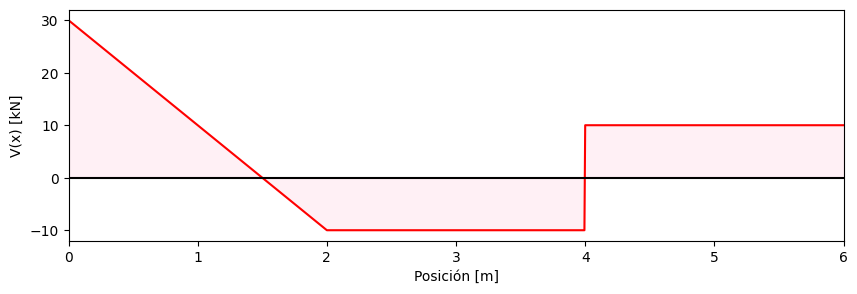

In [17]:
grafico_funcion_viga(xg, V(xg), "V(x) [kN]")

### Maximos, minimos y puntos cero

In [18]:
# Cortante máximo y su posición
V_max = V(xg).max()
pos_V_max = xg[argmax(V(xg))]
print(f"El cortante máximo es V_max = {V_max:.2f} kN en x = {pos_V_max:.2f} m") 

El cortante máximo es V_max = 30.00 kN en x = 0.00 m


In [19]:
# Cortante minimo y su posición
V_min = V(xg).min()
pos_V_min = xg[argmin(V(xg))]
print(f"El cortante mínimo es V_min = {V_min:.2f} kN en x = {pos_V_min:.2f} m")

El cortante mínimo es V_min = -10.00 kN en x = 3.20 m


In [20]:
# Puntos de cortante nulos
pos_V_cero_1 = xg[argmin(abs(V(xg)))]
pos_V_cero_2 = 4                        # Punto de carga puntual
print(f"Los puntos de cortante nulo están en x = {pos_V_cero_1:.2f} m y en x = {pos_V_cero_2:.2f} m")

Los puntos de cortante nulo están en x = 1.50 m y en x = 4.00 m


## Gráfico de momento flector

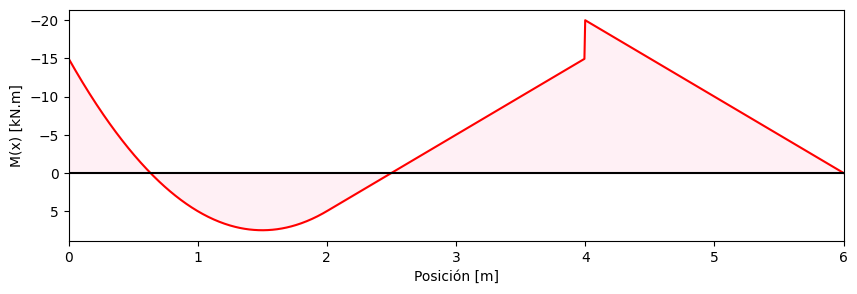

In [21]:
grafico_funcion_viga(xg, M(xg), "M(x) [kN.m]", momento=True)

### Maximos, minimos y puntos cero

In [22]:
# Momento máximo y su posición
M_max = M(xg).max()
pos_M_max = xg[argmax(M(xg))]
print(f"El momento máximo es M_max = {M_max:.2f} kN.m en x = {pos_M_max:.2f} m")

El momento máximo es M_max = 7.50 kN.m en x = 1.50 m


In [23]:
# Momento minimo y su posición
M_min = M(xg).min()
pos_M_min = xg[argmin(M(xg))]
print(f"El momento mínimo es M_min = {M_min:.2f} kN.m en x = {pos_M_min:.2f} m")

El momento mínimo es M_min = -20.00 kN.m en x = 4.00 m


In [24]:
# Puntos de momento nulos 
# Rango de valores minimos para encontrar los ceros del momento
x1 = linspace(0.000001, 1.5, 1000)
x2 = linspace(1.500001, 4, 1000)
x3 = linspace(4.000001, 6, 1000)

pos_M_cero_1 = x1[argmin(abs(M(x1)))]
pos_M_cero_2 = x2[argmin(abs(M(x2)))]
pos_M_cero_3 = x3[argmin(abs(M(x3)))]
print(f"Los puntos de momento nulo están en x = {pos_M_cero_1:.2f} m, x = {pos_M_cero_2:.2f} m y x = {pos_M_cero_3:.2f} m")


Los puntos de momento nulo están en x = 0.63 m, x = 2.50 m y x = 6.00 m


## Grafico de la deformada de la viga (no se pide pero se anexa por si acaso)

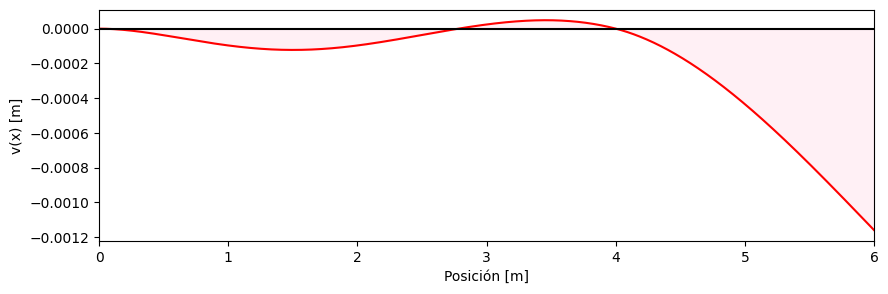

In [25]:
grafico_funcion_viga(xg, v(xg), "v(x) [m]")

## Gráfico esfuerzo normal en x

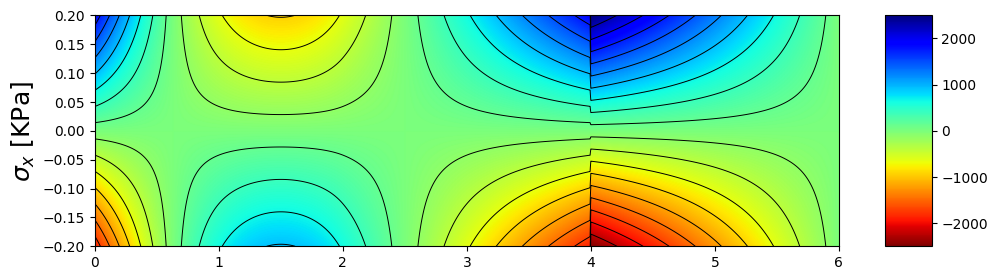

In [26]:
dibujar_esf_def(r"$\sigma_x$ [KPa]", sx(xi,yi), xi, yi)

Maximos, minimos y puntos cero

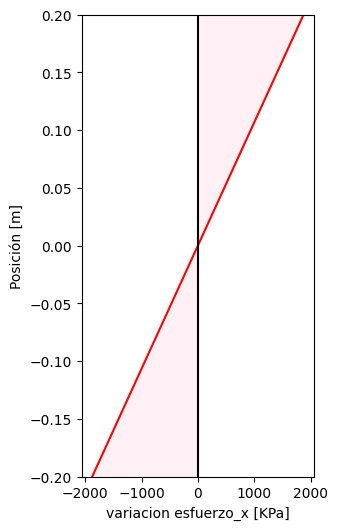

El esfuerzo normal máximo en x es sx_max = 2500.00 kPa
El esfuerzo normal mínimo en x es sx_min = -2500.00 kPa
El esfuerzo normal maximo y minimo se presenta en la coordenada de X donde el momento es maximo absoluto para una sección rectangular 
Así mismo, el esfuerzo normal es nulo en los puntos donde el momento es nulo y en la fibra neutra de la sección


In [27]:
grafico_funcion_esfuerzo_seccion(yg, sx(pos_V_max,yg), r"variacion esfuerzo_x [KPa]")

# Máximo y mínimo esfuerzo normal en x
sx_max = sx(pos_M_min, yg).max()
sx_min = sx(pos_M_min, yg).min()
print(f"El esfuerzo normal máximo en x es sx_max = {sx_max:.2f} kPa")
print(f"El esfuerzo normal mínimo en x es sx_min = {sx_min:.2f} kPa")
print("El esfuerzo normal maximo y minimo se presenta en la coordenada de X donde el momento es maximo absoluto para una sección rectangular", 
      "\nAsí mismo, el esfuerzo normal es nulo en los puntos donde el momento es nulo y en la fibra neutra de la sección")

## Gráfico esfuerzo normal en Y

Cabe resaltar que, debido a la diferencia entre las magnitudes del esfuerzo normal en Y para la carga distribuida y para las cargas puntuales (halladas por medio de "Flamant"), se optó por graficar ambos casos de manera individual para una mejor visualizacion y debido a la poca, o nula, aportacion de las cargas puntuales en la distribucion del esfuerzo $\sigma_y$, se opta por usar como este valor solo lo aportado por la carga distribuida para el resto del desarrollo del taller.

### Esfuerzo normal en Y para la carga distribuida

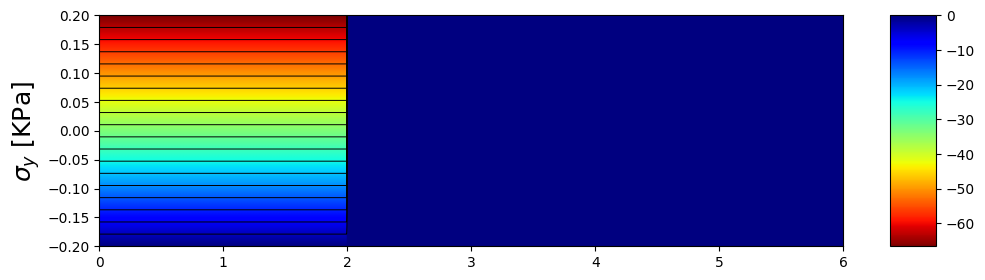

In [28]:
dibujar_esf_def(r"$\sigma_y$ [KPa]", sy_dist(xi,yi), xi, yi)

El gráfico de la carga distribuida muestra una variación suave y predecible donde el esfuerzo máximo en la superficie es exactamente igual a la presión aplicada ($q/b$). Siendo así que, satisface perfectamente las condiciones de frontera en la altura: $\sigma_y$ es máximo en la cara superior y estrictamente cero en la cara inferior.

### Esfuerzo normal en Y para las cargas puntuales

<lambdifygenerated-8>:2: RuntimeWarning: invalid value encountered in divide
  return 6.36619772367581*(y - 0.2)**3/((x - 6)**2 + (y - 0.2)**2)**2 - 12.7323954473516*(y + 0.2)**3/((x - 4)**2 + (y + 0.2)**2)**2 - 19.0985931710274*(y + 0.2)**3/(x**2 + (y + 0.2)**2)**2


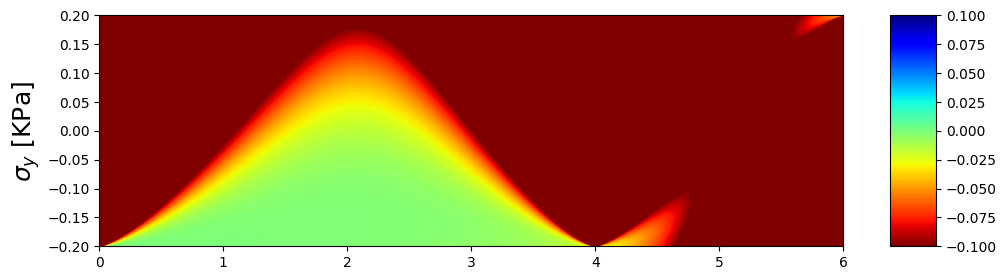

In [29]:
dibujar_esf_def(r"$\sigma_y$ [KPa]", sy_points(xi,yi), xi, yi)

La solución de Flamant (cargas puntuales), muestra cómo el esfuerzo se irradia y disipa rápidamente dentro del material, validando el Principio de Saint-Venant (el efecto local desaparece al alejarse del punto de aplicación). Sin embargo, la magnitud de los esfuerzos obtenidos no es lo suficientemente grande como para ser tenida en cuenta a comparacion de los generados por una carga distribuida, siendo así que puede llegar a ser despreciable pero generar problemas de punzonamiento si excede cierto limite.

## Gráfico esfuerzo cortante

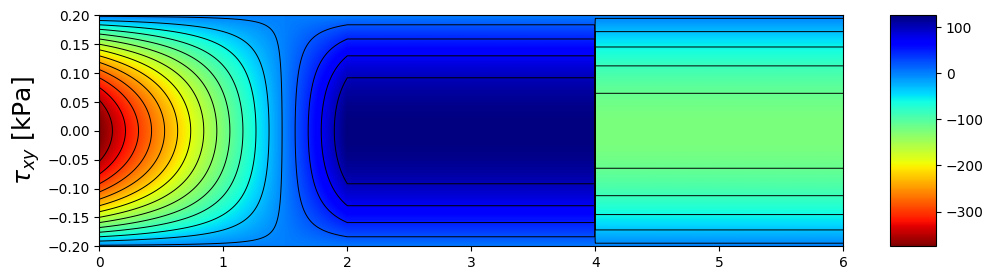

In [30]:
dibujar_esf_def(r"$\tau_{xy}$ [kPa]", txy(xi,yi), xi, yi)

Maximos, minimos y puntos cero

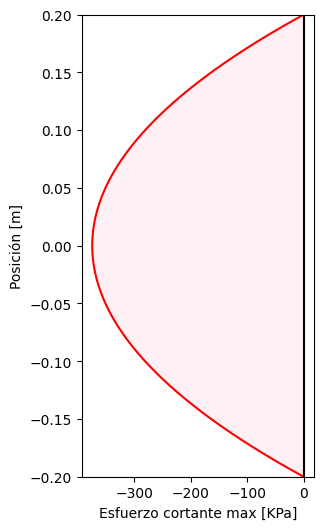

El esfuerzo cortante minimo es txy = -375.00 kPa


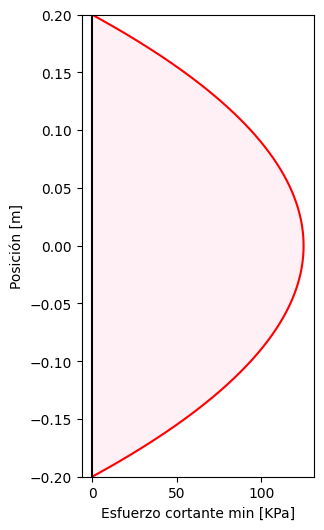

El esfuerzo cortante máximo es txy = 125.00 kPa 
Así mismo, el esfuerzo cortante es nulo en los puntos donde la fuerza cortante es nula y en los extremos de la sección


In [31]:
grafico_funcion_esfuerzo_seccion(yg, txy(pos_V_max,yg), r"Esfuerzo cortante max [KPa]")

# Minimo esfuerzo cortante
txy_min = txy(pos_V_max, yg).min()
print(f"El esfuerzo cortante minimo es txy = {txy_min:.2f} kPa")

grafico_funcion_esfuerzo_seccion(yg, txy(pos_V_min,yg), r"Esfuerzo cortante min [KPa]")

# Maximo esfuerzo cortante
txy_max = txy(pos_V_min, yg).max()
print(f"El esfuerzo cortante máximo es txy = {txy_max:.2f} kPa",
      "\nAsí mismo, el esfuerzo cortante es nulo en los puntos donde la fuerza cortante es nula y en los extremos de la sección")

## Gráfico de deformacion longitudinal en X

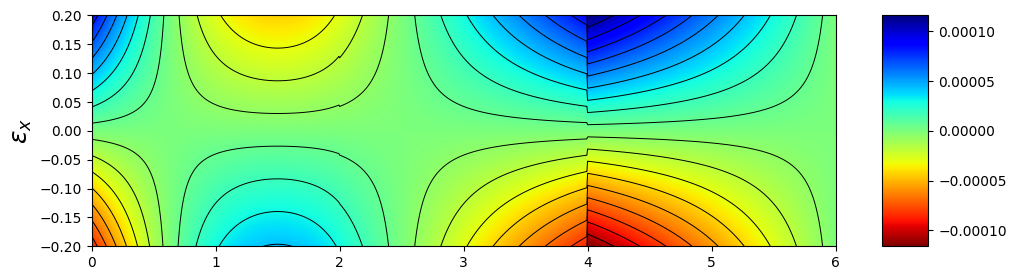

In [32]:
dibujar_esf_def(r"$\varepsilon_x$", ex(xi,yi), xi, yi)

Máximos y minimos

In [33]:
def find_extremos_deformacion(func_2d, xi, yi, nombre="deformación"):
    vals = func_2d(xi, yi)
    
    imax, jmax = unravel_index(argmax(vals), vals.shape)
    imin, jmin = unravel_index(argmin(vals), vals.shape)
    
    x_max, y_max = xi[imax, jmax], yi[imax, jmax]
    x_min, y_min = xi[imin, jmin], yi[imin, jmin]
    
    val_max = vals[imax, jmax]
    val_min = vals[imin, jmin]
    
    print(f"{nombre} máximo = {val_max:.6e} en x = {x_max:.4f} m, y = {y_max:.4f} m")
    print(f"{nombre} mínimo = {val_min:.6e} en x = {x_min:.4f} m, y = {y_min:.4f} m")
    
    return {"max": val_max, "x_max": x_max, "y_max": y_max,
            "min": val_min, "x_min": x_min, "y_min": y_min}

res_ex = find_extremos_deformacion(ex, xi, yi, "εx")


εx máximo = 1.160733e-04 en x = 4.0000 m, y = 0.2000 m
εx mínimo = -1.160733e-04 en x = 4.0000 m, y = -0.2000 m


Del mismo modo que se obtiene en el gráfico del esfuerzo normal en X, las deformaciones que son aproximadamente cero se presentan en los puntos como lo son la fibra neutra de la sección y los puntos de momento nulo descritos anteriormente, esto se debe a la gran diferencia de magnitud entre ambos esfuerzos $\sigma_x$ y $\sigma_y$, donde el que posee una mayor influencia es el esfuerzo normal en X, teniendo en cuenta tambien que el esfuerzo normal en Y se ve reducida por el coeficiente de Poisson; y por lo tanto los puntos donde este esfuerzo es nulo son aproximadamente los mismos para la deformacion $\varepsilon_x$.

## Gráfico de deformación longitudinal en Y

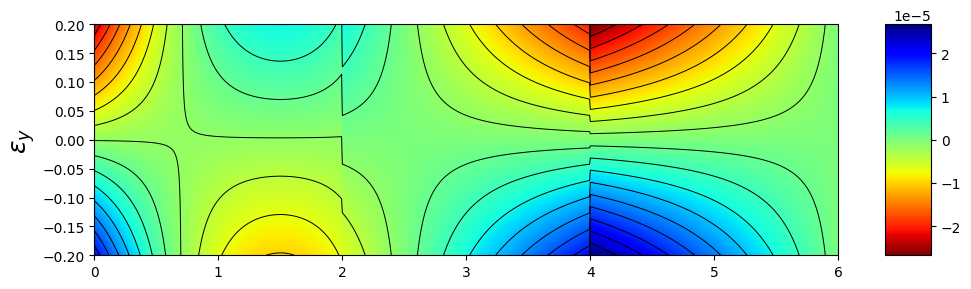

In [34]:
dibujar_esf_def(r"$\varepsilon_y$", ey(xi,yi), xi, yi)

Máximos y minimos

In [35]:
res_ey = find_extremos_deformacion(ey, xi, yi, "εy")

εy máximo = 2.669687e-05 en x = 4.0000 m, y = -0.2000 m
εy mínimo = -2.669687e-05 en x = 4.0000 m, y = 0.2000 m


De manera análoga a lo observado en la deformación longitudinal en X, las deformaciones en Y ($\varepsilon_y$) resultan aproximadamente cero en la fibra neutra y en los puntos de momento nulo pero con la diferencia significativa de que ahora se ve una mayor influencia de el esfuerzo normal en Y. Esto se explica por el Efecto de Poisson y la predominancia de la magnitud del esfuerzo $\sigma_x$ sobre $\sigma_y$ en la mayor parte de la viga (para valores de x > 2m); al ser $\sigma_x$ el componente dominante, este induce una deformación transversal proporcional en Y (contracción o dilatación). Por consiguiente, los puntos donde el esfuerzo longitudinal se anula coinciden con aquellos donde la deformación transversal $\varepsilon_y$ es prácticamente nula, salvo en la vecindad inmediata de las cargas aplicadas donde $\sigma_y$ tiene una influencia local significativa.

## Gráfico de deformacion longitudinal en Z

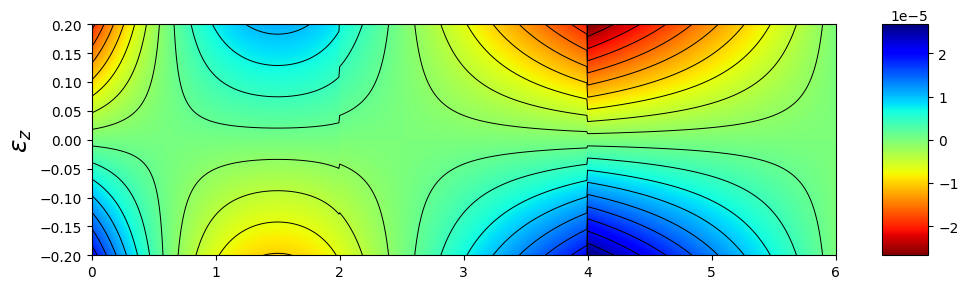

In [36]:
dibujar_esf_def(r"$\varepsilon_z$", ez(xi,yi), xi, yi)

Máximos y minimos

In [37]:
res_ez = find_extremos_deformacion(ez, xi, yi, "εz")

εz máximo = 2.669687e-05 en x = 4.0000 m, y = -0.2000 m
εz mínimo = -2.669687e-05 en x = 4.0000 m, y = 0.2000 m


Al igual que se expuso anteriormente con las gráficas de las otras deformaciones longitudinales, se sabe que las maximas y minimas deformaciones coinciden con las encontradas en $\varepsilon_y$, esto debido a la influencia del $\sigma_x$ y teniendo en cuenta el coeficiente de Poisson. Del mismo modo, al igual que se expuso anteriormente los puntos de deformacion longitudinal en direccion Z nulos ($\varepsilon_z$ = 0) coinciden con los presentados en el gráfico del esfuerzo longitudinal en X. Por lo cual, debido a la influencia del esfuerzo $\sigma_x$ en la mayor parte de la longitud de la viga, y a la inexistencia de un esfuerzo $\sigma_z$ por tratarse de tension plana, los puntos donde $\varepsilon_z$ es practicamente nulo son aproximadamente iguales a los presentes en los demás gráficos de deformacion longitudinal.

## Gráfico deformación angular

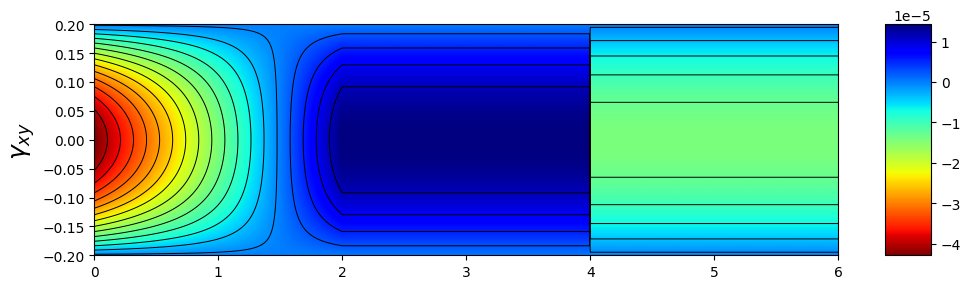

In [38]:
dibujar_esf_def(r"$\gamma_{xy}$", gxy(xi,yi), xi, yi)

In [39]:
res_ex = find_extremos_deformacion(gxy, xi, yi, "γxy")

γxy máximo = 1.427701e-05 en x = 3.2012 m, y = -0.0002 m
γxy mínimo = -4.283102e-05 en x = 0.0000 m, y = -0.0002 m


Dados los resultados obtenidos en el gráfico del esfuerzo cortante y ahora de la deformacion angular, se puede concluir que los resultados son análogos si nos basamos en la escala de colores presente y la similitud de ambos gráficos, esto debido a que al pasar de una variable a la otra por medio de la ley de Hooke, el resultado es basicamente dividir los valores obtenidos entre un coeficiente como lo es el modulo de cortante. De este modo, los puntos donde la deformación $\gamma_{xy}$ es maxima, minima o nula son aproximadamente los mismos encontrados en el analisis del esfuerzo cortante $\tau_{xy}$, y por ende los mismos puntos especificados en el analisis del gráfico de la fuerza cortante.

# Esfuerzos principales

## Esfuerzos principales y sus direcciones

In [40]:
# Revisión de valores en el punto donde σ1 es máximo
imax, jmax = unravel_index(argmax(s1), s1.shape)
x_pt = xi[imax, jmax]
y_pt = yi[imax, jmax]

print(f"En el punto máximo de σ1 (x={x_pt:.4f}, y={y_pt:.4f}):")
print(f"σx = {sx_vals[imax, jmax]:.2f} kPa")
print(f"σy = {sy_vals[imax, jmax]:.2f} kPa")
print(f"τxy = {txy_vals[imax, jmax]:.2f} kPa")
print(f"σ1 = {s1[imax, jmax]:.2f} kPa")
print("La dirección de σ1 con respecto al eje x es =", t1[imax, jmax]*180/pi, "grados")

En el punto máximo de σ1 (x=4.0000, y=0.2000):
σx = 2500.00 kPa
σy = 0.00 kPa
τxy = 0.00 kPa
σ1 = 2500.00 kPa
La dirección de σ1 con respecto al eje x es = 4.969616689786696e-16 grados


In [41]:
# Revisión de valores en el punto donde σ2 es minimo
imin, jmin = unravel_index(argmin(s2), s2.shape)
x_pt2 = xi[imin, jmin]
y_pt2 = yi[imin, jmin]

print(f"En el punto minimo de σ2 (x={x_pt2:.4f}, y={y_pt2:.4f}):")
print(f"σx = {sx_vals[imin, jmin]:.2f} kPa")
print(f"σy = {sy_vals[imin, jmin]:.2f} kPa")
print(f"τxy = {txy_vals[imin, jmin]:.2f} kPa")
print(f"σ2 = {s2[imin, jmin]:.2f} kPa")
print("La dirección de σ2 con respecto al eje x es =", t2[imin, jmin]*180/pi, "grados")

En el punto minimo de σ2 (x=4.0000, y=-0.2000):
σx = -2500.00 kPa
σy = 0.00 kPa
τxy = 0.00 kPa
σ2 = -2500.00 kPa
La dirección de σ2 con respecto al eje x es = -4.969616689786696e-16 grados


Se concluye que los resultados anteriores se deben a la gran influencia del momento generado en en la coordenada x=4, lo cual conlleva a que los mayores esfuerzos se presenten alrededor de esta zona.

## Esfuerzo equivalente de Von Mises

Para un caso de Tensión Plana como el que se está trabajando (donde $\sigma_z = 0$), la fórmula es (seccion 16.6.5):$$\sigma_{VM} = \sqrt{((\sigma_1-\sigma_2)^2 + (\sigma_1)^2 + (\sigma_2)^2)/2}$$

In [42]:
# Esfuerzo equivalente de Von Mises
s_vm = sqrt(((s1 - s2)**2 +(s1)**2 + (s2)**2)/2)

# Evaluar si el esfuerzo equivalente de Von Mises supera la resistencia del material
s_vm_max = s_vm.max()
print(f"El esfuerzo equivalente de Von Mises máximo es s_vm_max = {s_vm_max:.2f} kPa")
if s_vm_max > fpc*1000:
    print(f"El material falla bajo el criterio de Von Mises. Esto debido a que {s_vm_max:.2f} kPa > {fpc*1000} kPa")
else:
    print(f"El material no falla bajo el criterio de Von Mises. Esto debido a que {s_vm_max:.2f} kPa ≤ {fpc*1000} kPa")


El esfuerzo equivalente de Von Mises máximo es s_vm_max = 2500.00 kPa
El material no falla bajo el criterio de Von Mises. Esto debido a que 2500.00 kPa ≤ 21000 kPa


## Esfuerzo equivalente de Tresca

El Criterio de Tresca considera el esfuerzo cortante máximo absoluto. Como $\sigma_z=0$ se aplica para tension plana, el esfuerzo equivalente de Tresca es la mayor diferencia entre cualquiera de los tres principales (seccion 16.6.5) ($\sigma_1, \sigma_2, 0$):$$\sigma_{Tresca} = (\max\left( |\sigma_1 - \sigma_2|, |\sigma_1 - 0|, |\sigma_2 - 0| \right))/2$$

In [43]:
# Esfuerzo equivalente de Tresca
s_tresca = maximum(abs(s1), abs(s2), abs(s1 - s2))/2

# Evaluar si el esfuerzo equivalente de Tresca supera la resistencia del material
s_tresca_max = s_tresca.max()
print(f"El esfuerzo equivalente de Tresca máximo es s_tresca_max = {s_tresca_max:.2f} kPa")
if s_tresca_max > fpc*1000:
    print(f"El material falla bajo el criterio de Tresca. Esto debido a que {s_tresca_max:.2f} kPa > {fpc*1000} kPa")
else:
    print(f"El material no falla bajo el criterio de Tresca. Esto debido a que {s_tresca_max:.2f} kPa ≤ {fpc*1000} kPa")

El esfuerzo equivalente de Tresca máximo es s_tresca_max = 1250.00 kPa
El material no falla bajo el criterio de Tresca. Esto debido a que 1250.00 kPa ≤ 21000 kPa


## Patrón de agrietamiento aproximado de la viga

In [44]:
def dibujar_esf_def2(titulo, f, x, y, angulo=None):
    # 1. Configuración de niveles (usando percentiles para evitar picos extremos)
    vmin, vmax = percentile(f, 2), percentile(f, 98)
    curvas = linspace(vmin, vmax, 20)
    
    plt.figure(figsize=(20, 4))
    
    # 2. Graficar el mapa de colores (fondo)
    # Usamos toda la resolución original para el color
    im = plt.pcolormesh(x, y, f, vmin=vmin, vmax=vmax, shading='gouraud', cmap='jet_r')
    
    # 3. Graficar las líneas de dirección (trayectorias)
    if angulo is not None:
        # 'paso' define cada cuántos puntos dibujamos una línea.
        # Aumenta este número si aún se ve muy negro (ej. 8, 10, 15)
        paso = 60
        
        # Creamos sub-matrices saltando índices [inicio:fin:paso]
        x_sub = x[::paso, ::paso]
        y_sub = y[::paso, ::paso]
        f_sub = f[::paso, ::paso]
        
        # Manejo de lista de ángulos
        if isinstance(angulo, ndarray):
            angulo = [angulo]
            
        for ang in angulo:
            # Recortamos también el ángulo con el mismo paso
            ang_sub = ang[::paso, ::paso]
            
            # Calculamos componentes U y V
            # Nota: Tu escala original abs(f)**(1/3) está bien para suavizar diferencias
            escala_ang = abs(f_sub)**(1/3)
            
            u = escala_ang * cos(ang_sub)
            v = escala_ang * sin(ang_sub)
            
            # Graficamos con quiver
            # scale: Controla la longitud (mayor número = flechas más cortas)
            # width: Grosor de la línea
            plt.quiver(x_sub, y_sub, u, v,
                       headwidth=0, headlength=0, headaxislength=0, # Sin cabeza de flecha
                       pivot="middle", color='k', 
                       scale=80, width=0.0015, alpha=0.6)

    # 4. Contornos y decoración
    plt.contour(x, y, f, levels=curvas, colors='k', linestyles='-', linewidths=0.5, alpha=0.3)
    
    cbar = plt.colorbar(im, aspect=10)
    plt.ylabel(titulo, fontsize=18)
    plt.xlim(x.min(), x.max())
    plt.ylim(y.min(), y.max())
    plt.show()

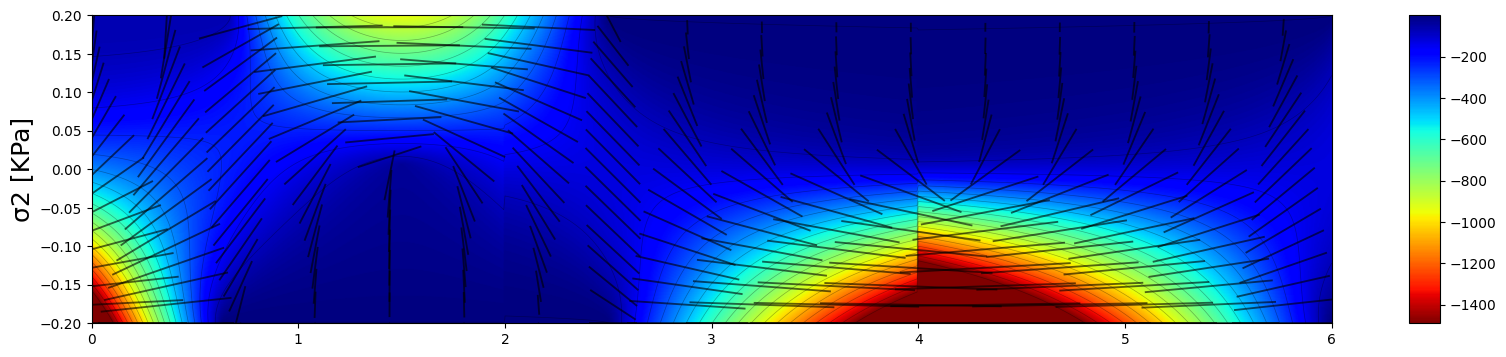

In [45]:
# Patron de agrietamiento aproximado, es decir, trayectorias de maxima compresion 

dibujar_esf_def2(r"σ2 [KPa]", s2, xi, yi, t2)

## Refuerzo optimo aproximado 

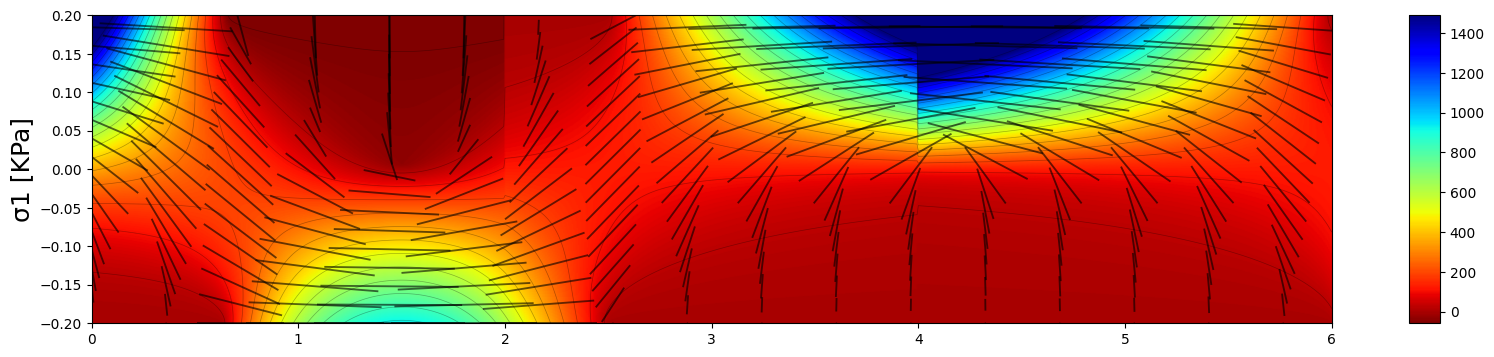

In [46]:
# Refuerzo optimo aproximado, es decir, trayectorias de maxima tension

dibujar_esf_def2(r"σ1 [KPa]", s1, xi, yi, t1)

## Refuerzo convencional aproximado 

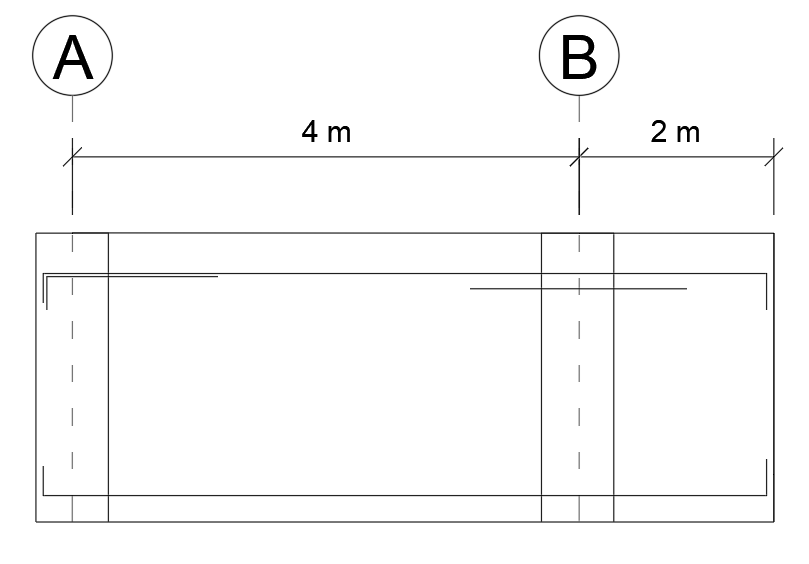

Se propone el tipo de refuerzo longitudinal dado para resistir los esfuerzos y momentos aplicados en los puntos criticos como lo son los apoyos que deben resistir esfuerzos de grandes magnitudes en la parte superior, por lo cual se propone el uso de un refuerzo extra en estas zonas que servirá para el manejo del momento flector en estos puntos.